# Pipeline de imagen del nodo — Banco de Pruebas y Análisis LoRa

Cargá una imagen, ajustá los umbrales de descarte (negro, cielo, verde), analizá el peso y la paquetización por LoRa, y aplicá los filtros **Bitmask** y **Maxpool**.

Toda la lógica vive en `pipeline_sim.py` (mismo código que el firmware del ESP32).

**Ejecutar:**
```bash
cd Desarrollo/Pruebas
uv sync
uv run jupyter lab notebooks/1_fuego.ipynb
```
En el editor, elegí el kernel **Pruebas (uv)** (`.venv/bin/python`).

In [5]:
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from ipywidgets import IntSlider, interact

# Raíz del banco de pruebas = la carpeta que contiene `modulos/`. Así el notebook anda
# tanto abierto desde notebooks/ como desde Pruebas/.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}; "
                       "abrí el notebook dentro de Desarrollo/Pruebas/")
sys.path.insert(0, str(RAIZ / "modulos"))
DATOS, SALIDAS = RAIZ / "datos", RAIZ / "salidas"


def ruta_salida(nombre):
    """Ruta dentro de salidas/, creando la carpeta si hace falta.

    Se crea al escribir y no al importar: así la celda de exportar funciona aunque
    se la ejecute sola después de reiniciar el kernel.
    """
    SALIDAS.mkdir(parents=True, exist_ok=True)
    return SALIDAS / nombre
import pipeline_sim as ps

CMAP_RG = LinearSegmentedColormap.from_list("rg", ["#0a0c0f", "#1a3a1a", "#ff6b2b"])
CMAP_HIT = ListedColormap(["#00000000", "#ff2b2b"])      # 0 transparente, 1 rojo
CMAP_REGIONS = ListedColormap(["#0a0c0f", "#2b2b2b", "#3a75c4", "#2ba84a", "#ff6b2b"]) # Fondo, Negro, Cielo, Verde, Interes
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})


def panel(ax, data, titulo, **kw):
    ax.imshow(data, interpolation="nearest", **kw)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")

## 1 · Cargar la imagen

Subila con el botón, o dejá `RUTA` apuntando a un archivo. Sin ninguna de las dos:
escena sintética (campo seco + frente de llama + cielo + vegetación).

In [3]:
import ipywidgets as W

subir = W.FileUpload(accept="image/*", multiple=False, description="Subir imagen")
subir

FileUpload(value=(), accept='image/*', description='Subir imagen')

Después de subir (o de cambiar `RUTA`), **volvé a ejecutar la celda de abajo**:
recalcula todo el pipeline y el resto del notebook lee de `P`.

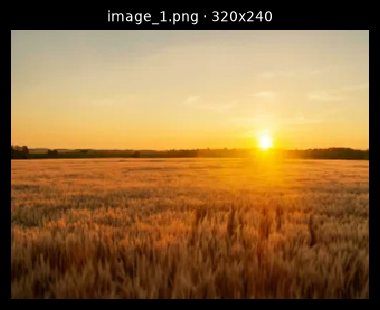

In [6]:
RUTA = subir         # p.ej. DATOS / "image_1.png"

if subir.value:
    arch = subir.value[0]
    fuente, origen = BytesIO(arch["content"]), arch["name"]
else:
    fuente, origen = RUTA, (str(RUTA) if RUTA else "escena sintetica")

rgb888 = ps.load_qvga(fuente)          # cualquier resolucion -> QVGA 320x240
P = ps.preparar(rgb888)                # etapas 0,1,3,4 + reconstruccion RX + regiones

fig, ax = plt.subplots(figsize=(4.2, 3.2))
panel(ax, rgb888, f"{origen} · {ps.SRC_W}x{ps.SRC_H}")
plt.show()

## 2 · Etapa 0 — reducción a 16×16

BOX average de bloques de 20×15 px con recíproco fijo (sin división, como en el ESP32).
El sesgo mide cuánto se aparta ese recíproco de la división exacta.

bloque 20x15 = 300 px/celda
reciproco 14318>>22   sesgo vs division exacta: +2.35 %


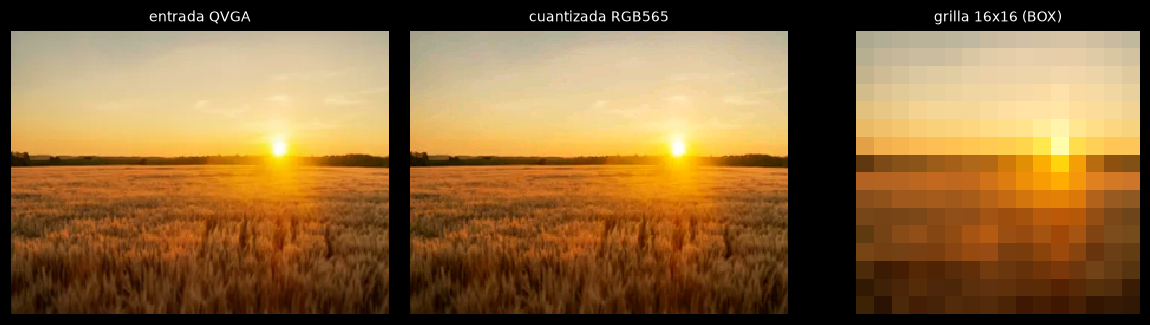

In [7]:
exacto = ps.box_downsample(ps.to_rgb565(rgb888),
                           round(2 ** ps.BOX_SHIFT / (ps.BLOCK_W * ps.BLOCK_H)))
sesgo = 100 * (P["grid"].astype(float).mean() / exacto.astype(float).mean() - 1)
print(f"bloque {ps.BLOCK_W}x{ps.BLOCK_H} = {ps.BLOCK_W*ps.BLOCK_H} px/celda")
print(f"reciproco {ps.BOX_RECIP}>>{ps.BOX_SHIFT}   sesgo vs division exacta: {sesgo:+.2f} %")

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
panel(ax[0], rgb888, "entrada QVGA")
panel(ax[1], ps.to_rgb565(rgb888), "cuantizada RGB565")
panel(ax[2], P["grid"], "grilla 16x16 (BOX)")
plt.tight_layout(); plt.show()

## 3 · Etapa 1 — índice cromático

`R-G` es el elegido. La columna `sep(sigma)` es el margen entre llama y fondo
en desvíos estándar: cuanto más alto, mejor discrimina.

indice       min   max    media  sep(sigma)
R-G            3    99     46.5        3.51
R-B           29   255    105.4        2.50
R/(G+B)        0   255     70.7       -0.97
gris        -125   122      7.7       -0.01


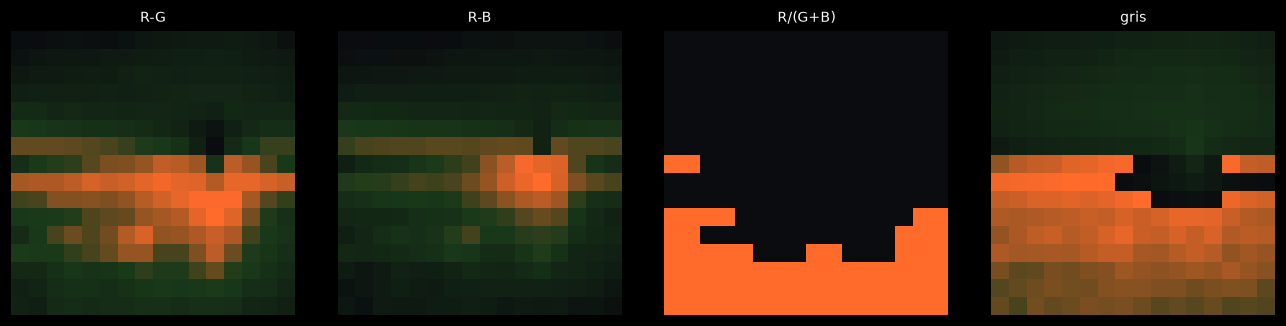

In [8]:
idxs = ps.indices(P["grid"])
ref = idxs["R-G"] > 80                       # referencia para medir separabilidad

print(f"{'indice':<10}{'min':>6}{'max':>6}{'media':>9}{'sep(sigma)':>12}")
for k, v in idxs.items():
    print(f"{k:<10}{v.min():>6}{v.max():>6}{v.mean():>9.1f}{ps.separacion(v, ref):>12.2f}")

fig, ax = plt.subplots(1, 4, figsize=(12, 2.9))
for a, (k, v) in zip(ax, idxs.items()):
    panel(a, v, k, cmap=CMAP_RG)
plt.tight_layout(); plt.show()

## 4 · Filtrado de Áreas No Deseadas (Negro, Cielo, Verde)

Para evitar falsas alarmas y reducir datos no relevantes antes de los filtros posteriores, descartamos celdas que corresponden a:
- **Áreas Negras / Oscuras**: Píxeles con $R, G, B < \text{th\_black}$ (fondo sin luz, padding).
- **Cielo / Azul**: Píxeles donde domina el componente azul ($B - R > \text{th\_sky\_diff}$ y $B > G$).
- **Vegetación Verde**: Píxeles donde domina el componente verde ($G - R > \text{th\_green\_diff}$ y $G > B$).

Las celdas restantes forman la **Zona de Interés (`interest_mask`)**.

In [ ]:
@interact(th_black=IntSlider(35, 0, 100, 5, description="Negro <"),
          th_sky_diff=IntSlider(15, 0, 100, 5, description="Cielo (B-R) >"),
          th_green_diff=IntSlider(10, 0, 100, 5, description="Verde (G-R) >"))
def ver_descarte_regiones(th_black, th_sky_diff, th_green_diff):
    reg = ps.classify_regions(P["grid"], th_black, th_sky_diff, th_green_diff)
    P["regions"] = reg  # Actualiza regiones en P

    n_black = int(reg["black"].sum())
    n_sky = int(reg["sky"].sum())
    n_green = int(reg["green"].sum())
    n_interest = int(reg["interest"].sum())
    n_total = reg["interest"].size

    fig, ax = plt.subplots(1, 5, figsize=(14, 3))
    panel(ax[0], P["grid"], "BOX 16x16 Original")
    panel(ax[1], reg["black"], f"Negros ({n_black}/{n_total})", cmap="gray")
    panel(ax[2], reg["sky"], f"Cielo ({n_sky}/{n_total})", cmap="Blues")
    panel(ax[3], reg["green"], f"Verde ({n_green}/{n_total})", cmap="Greens")
    panel(ax[4], reg["interest"], f"Zona de Interés ({n_interest}/{n_total})", cmap="Oranges")
    plt.tight_layout(); plt.show()

    print(f"Resumen de Celdas (16x16 = {n_total}):")
    print(f"  - Negras/Oscuras: {n_black:>3} ({100*n_black/n_total:.1f}%)")
    print(f"  - Cielo/Azul:     {n_sky:>3} ({100*n_sky/n_total:.1f}%)")
    print(f"  - Vegetación:     {n_green:>3} ({100*n_green/n_total:.1f}%)")
    print(f"  - Descartadas:    {n_total - n_interest:>3} ({100*(n_total - n_interest)/n_total:.1f}%)")
    print(f"  -> ZONA DE INTERÉS RETENIDA: {n_interest:>3} ({100*n_interest/n_total:.1f}%)")

interactive(children=(IntSlider(value=35, description='Negro <', step=5), IntSlider(value=15, description='Cie…

## 5 · Análisis de Tamaño de la Imagen y Paquetización LoRa

Analizamos cuánto pesa la imagen en cada formato (Bytes y KB) y cuántos paquetes **LoRa** se requerirían para su transmisión completa según el tamaño de **Payload MTU** (ej: 222 Bytes máximo por paquete en LoRaWAN o 240 Bytes en nodo de pruebas).

Cálculo de Airtime considerado a **SF10 / 125 kHz / CR 4:5**.

In [10]:
@interact(payload_mtu=IntSlider(222, 32, 255, 10, description="Payload MTU (B)"))
def evaluar_paquetes_lora(payload_mtu):
    n_interest = int(P["regions"]["interest"].sum())

    formatos = [
        ("QVGA RGB888 crudo (320x240)", ps.SRC_W * ps.SRC_H * 3),
        ("QVGA RGB565 crudo (320x240)", ps.SRC_W * ps.SRC_H * 2),
        ("Grilla 16x16 RGB (tras BOX)", ps.GRID * ps.GRID * 3),
        ("Índice R-G 16x16 uint8", ps.GRID * ps.GRID),
        (f"Celdas de Interés 16x16 R-G ({n_interest} celdas + bitmask 32B)", n_interest + 32),
        ("Grilla 8x8 R-G (tras Maxpool 2x2)", 64),
        ("Paquete DWT Completo (LL+LH+HL+escalares+bitmask)", 243),
        ("Early Exit (sin fuego / 1 byte)", 1),
    ]

    print(f"{'Formato / Representación':<48} {'Bytes':>8} {'KB':>8} {'Paquetes':>10} {'Airtime Total':>15}")
    print("-" * 95)
    for nombre, b in formatos:
        analysis = ps.lora_packet_analysis(b, payload_mtu=payload_mtu)
        pkts = analysis["num_packets"]
        airtime_sec = analysis["total_airtime"]
        if airtime_sec >= 60:
            time_str = f"{airtime_sec/60:.2f} min"
        else:
            time_str = f"{airtime_sec*1000:.1f} ms"
        kb = b / 1024.0
        print(f"{nombre:<48} {b:>8} {kb:>8.2f} {pkts:>10} {time_str:>15}")

    print("-" * 95)
    print("Conclusión LoRa:")
    print("  - Transmitir la imagen QVGA cruda por LoRa requeriría cientos/miles de paquetes")
    print("    y decenas de minutos de tiempo al aire, lo cual es inaceptable por consumo y regulaciones.")
    print("  - Al reducir a grilla 16x16 / DWT / Bitmask, el payload entra en 1 SOLO PAQUETE (243 B) o 1 B (Early Exit).")

interactive(children=(IntSlider(value=222, description='Payload MTU (B)', max=255, min=32, step=10), Output())…

## 6 · Filtro Bitmask Combinado y Filtro Maxpool 2×2

Una vez descartadas las áreas no deseadas (negro, cielo, verde):
1. **Filtro Bitmask Combinado**: Aplica los umbrales de fuego ($R > \text{th\_r}$, $R-G > \text{th\_rg}$, $B < \text{th\_b}$) **únicamente sobre las celdas de la Zona de Interés**.
2. **Filtro Maxpool 2×2**: Submuestrea la grilla de $16 \times 16$ a $8 \times 8$ (64 celdas / 64 bytes). Al usar **Maxpool**, si en un bloque de 2×2 hay una celda con alto índice $R-G$ o presencia de llama, **su valor pico se conserva**, evitando perder pequeñas alertas de fuego.

In [29]:
@interact(th_r=IntSlider(ps.TH_R, 0, 255, 1, description="R >"),
          th_rg=IntSlider(ps.TH_RG, 0, 255, 1, description="R-G >"),
          th_b=IntSlider(ps.TH_B, 0, 255, 1, description="B <"),
          usar_filtro_region=W.Checkbox(value=True, description="Filtrar Negro/Cielo/Verde"))
def ajustar_bitmask_y_maxpool(th_r, th_rg, th_b, usar_filtro_region):
    hit_raw, n_raw, _ = ps.transmitir(P, th_r, th_rg, th_b, use_region_filter=False)
    hit_filt, n_filt, pkt = ps.transmitir(P, th_r, th_rg, th_b, use_region_filter=usar_filtro_region)

    # Maxpool 2x2 sobre el indice R-G y sobre el bitmask de llama
    idx_maxpool = ps.maxpool2d(P["idx"], pool_size=2)
    hit_maxpool = ps.maxpool2d(hit_filt.astype(np.uint8), pool_size=2) > 0

    fig, ax = plt.subplots(2, 3, figsize=(12, 6.5))
    panel(ax[0, 0], rgb888, "Entrada QVGA")
    panel(ax[0, 1], P["regions"]["interest"], "Zona de Interés (16x16)", cmap="Oranges")
    panel(ax[0, 2], hit_raw, f"Bitmask Sin Filtrar ({n_raw}/256)", cmap="gray")

    panel(ax[1, 0], hit_filt, f"Bitmask Filtrado Interés ({n_filt}/256)", cmap="gray")
    panel(ax[1, 1], idx_maxpool, "Índice R-G (Maxpool 8x8)", cmap=CMAP_RG, vmin=0, vmax=170)
    panel(ax[1, 2], hit_maxpool, f"Bitmask (Maxpool 8x8: {int(hit_maxpool.sum())}/64)", cmap="gray")
    plt.tight_layout(); plt.show()

    airtime = ps.lora_airtime(min(len(pkt), 255)) * 1000
    print(f"Resultados de Filtrado y Reducción:")
    print(f"  - Llama detectada sin filtrar región:  {n_raw}/256 celdas")
    print(f"  - Llama detectada en Zona de Interés:  {n_filt}/256 celdas")
    print(f"  - Celdas activadas en Maxpool 8x8:     {int(hit_maxpool.sum())}/64 bloques")
    print(f"  - Peso del Bitmask 16x16: 32 Bytes | Peso del Bitmask 8x8: 8 Bytes")
    print(f"  - Paquete LoRa generado: {len(pkt)} Bytes (Airtime: {airtime:.1f} ms)")

interactive(children=(IntSlider(value=150, description='R >', max=255), IntSlider(value=50, description='R-G >…

## 7 · Barrido: sensibilidad al umbral

Cuántas celdas quedan marcadas al mover un umbral con los otros dos fijos.
El escalón sirve para elegir el valor: buscá la meseta, no el borde.

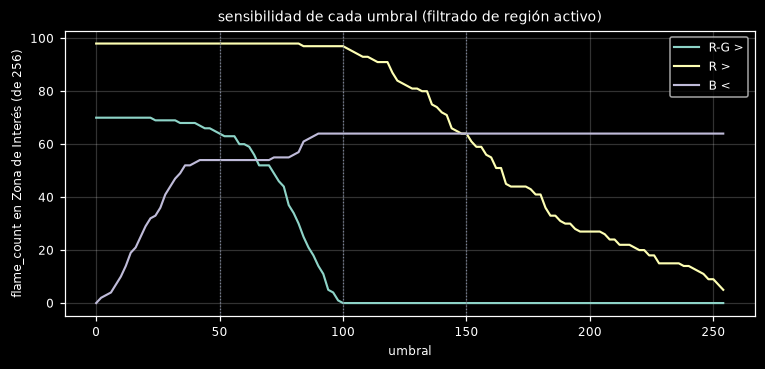

In [23]:
ejes = np.arange(0, 256, 2)
curvas = {
    "R-G >":  [ps.transmitir(P, ps.TH_R, t, ps.TH_B, use_region_filter=True)[1] for t in ejes],
    "R >":    [ps.transmitir(P, t, ps.TH_RG, ps.TH_B, use_region_filter=True)[1] for t in ejes],
    "B <":    [ps.transmitir(P, ps.TH_R, ps.TH_RG, t, use_region_filter=True)[1] for t in ejes],
}

fig, ax = plt.subplots(figsize=(7, 3.4))
for etiqueta, y in curvas.items():
    ax.plot(ejes, y, label=etiqueta, lw=1.4)
for v, c in [(ps.TH_R, "R >"), (ps.TH_RG, "R-G >"), (ps.TH_B, "B <")]:
    ax.axvline(v, color="#7a8399", ls=":", lw=0.8)
ax.set_xlabel("umbral"); ax.set_ylabel("flame_count en Zona de Interés (de 256)")
ax.set_title("sensibilidad de cada umbral (filtrado de región activo)", fontsize=9)
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 8 · Etapas 3 y 4 — DWT Haar y cuantización

La transformada concentra la energía en LL. `HH` se descarta: son 64 B menos
y casi no aporta a la reconstrucción.

LL: rango [    0,   299]  energia  92.9 %   -> 64 B uint8
LH: rango [  -77,    54]  energia   1.6 %   -> 64 B uint8
HL: rango [  -57,    94]  energia   5.2 %   -> 64 B uint8
HH: rango [  -18,    30]  energia   0.3 %   -> DESCARTADO


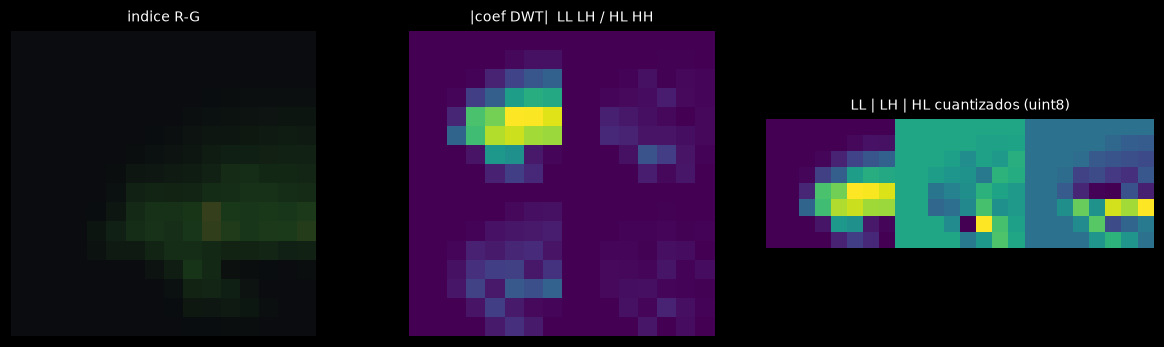

In [30]:
sb = ps.subbands(P["coef"])
energia = {k: float((v.astype(float) ** 2).sum()) for k, v in sb.items()}
total = sum(energia.values()) or 1.0

for i, k in enumerate(("LL", "LH", "HL")):
    print(f"{k}: rango [{P['scal'][2*i]:>5}, {P['scal'][2*i+1]:>5}]  "
          f"energia {100*energia[k]/total:>5.1f} %   -> 64 B uint8")
print(f"HH: rango [{sb['HH'].min():>5}, {sb['HH'].max():>5}]  "
      f"energia {100*energia['HH']/total:>5.1f} %   -> DESCARTADO")

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
panel(ax[0], P["idx"], "indice R-G", cmap=CMAP_RG, vmin=0, vmax=170)
panel(ax[1], np.abs(P["coef"]), "|coef DWT|  LL LH / HL HH", cmap="viridis")
panel(ax[2], np.hstack([q.reshape(8, 8) for q in P["qs"]]),
      "LL | LH | HL cuantizados (uint8)", cmap="viridis")
plt.tight_layout(); plt.show()

## 9 · Etapa 5 y receptor — qué se transmite y qué se recupera

etapa                                      bytes   vs QVGA
frame QVGA RGB565 320x240                 153600        1x
grilla 16x16 RGB tras BOX                    768      200x
indice R-G sin comprimir                     256      600x
DWT LL+LH+HL cuantizados                     192      800x
escalares min/max (6 x int16)                 12    12800x
bitmask de llama                              32     4800x
PAQUETE LORA COMPLETO                        243      632x

airtime SF10/125kHz CR4:5 -> 2172.9 ms

PSNR 44.08 dB   MAE 1.09   err max 6   corr 0.9979


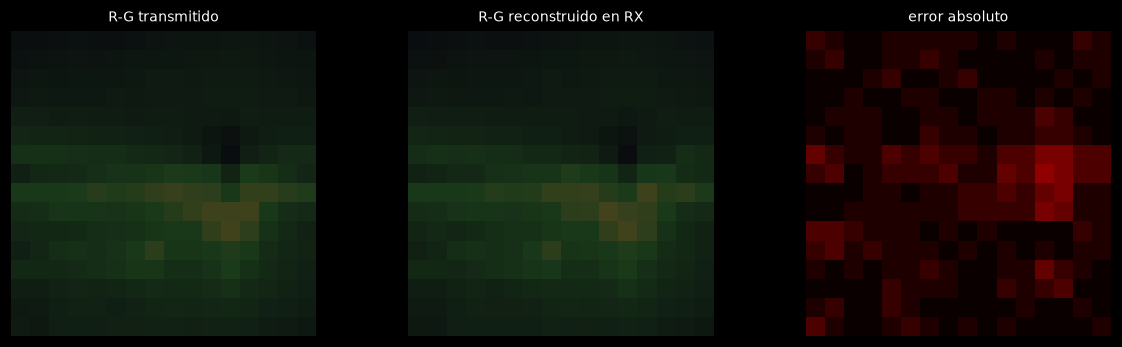

In [25]:
hit, n, pkt = ps.transmitir(P, use_region_filter=True)          # umbrales nominales
base = ps.SRC_W * ps.SRC_H * 2

print(f"{'etapa':<40}{'bytes':>8}{'vs QVGA':>10}")
for nombre, b in [(f"frame QVGA RGB565 {ps.SRC_W}x{ps.SRC_H}", base),
                  ("grilla 16x16 RGB tras BOX", ps.GRID * ps.GRID * 3),
                  ("indice R-G sin comprimir", ps.GRID * ps.GRID),
                  ("DWT LL+LH+HL cuantizados", 192),
                  ("escalares min/max (6 x int16)", 12),
                  ("bitmask de llama", 32),
                  ("PAQUETE LORA COMPLETO", len(pkt))]:
    print(f"{nombre:<40}{b:>8}{base/b:>9.0f}x")

print(f"\nairtime SF{ps.LORA_SF}/{ps.LORA_BW//1000}kHz CR4:5 -> "
      f"{ps.lora_airtime(min(len(pkt),255))*1000:.1f} ms")

err = np.abs(P["idx"] - P["idx_rec"])
print(f"\nPSNR {ps.psnr(P['idx'], P['idx_rec']):.2f} dB   "
      f"MAE {err.mean():.2f}   err max {err.max()}   "
      f"corr {np.corrcoef(P['idx'].ravel(), P['idx_rec'].ravel())[0,1]:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
panel(ax[0], P["idx"], "R-G transmitido", cmap=CMAP_RG, vmin=0, vmax=170)
panel(ax[1], P["idx_rec"], "R-G reconstruido en RX", cmap=CMAP_RG, vmin=0, vmax=170)
panel(ax[2], err, "error absoluto", cmap="hot", vmin=0, vmax=30)
plt.tight_layout(); plt.show()

## 10 · Exportar

El CSV tiene el mismo formato que el volcado UART del firmware: sirve para
comparar la grilla real del nodo contra esta simulación.

In [12]:
salida = ruta_salida("indice_rg.csv")
np.savetxt(salida, P["idx"], fmt="%d", delimiter=",")
print(f"{salida.resolve()}  ({salida.stat().st_size} B)")
print(f"paquete: {len(pkt)} B")
ruta_salida("paquete.bin").write_bytes(pkt)

/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/salidas/indice_rg.csv  (684 B)
paquete: 243 B


243